# FERM 3 — Assignment 2: Practical Mean–Variance Portfolio Construction

**Data:** 23 stocks, daily returns, 2016-01-04 → 2017-12-28 (502 observations), `portfolio.xlsx`, sheet `Daily_Returns_Raw_Data`.

This notebook mirrors the workbook cell-for-cell. Every quantity computed in Python has a named Excel counterpart, and the two agree to ~15 significant digits.

| Q | Question | Answer |
|---|---|---|
| 1 | Shrinkage estimate $\mu_1$ for IBM, $\alpha=0.9$ | **0.0003** |
| 2 | Min-variance weight in IBM, no short selling | **0.081** |
| 3 | Min-variance weight in IBM, leverage cap $M=0.1$ | **0.082** |
| 4 | Is $0.5x_1 + 0.5x_2$ still on the frontier? | **Yes** |
| 5 | Constraint for "≤ 10% of wealth in any one stock" | $x_i \le 0.1$ |

---

## Where each number lives in Excel

| Quantity | Excel location |
|---|---|
| Raw returns $R$ | `Daily_Returns_Raw_Data!B2:X503` |
| Sample covariance $V$ | `Shrinkaged_Q1&2!B4:X26` |
| $\sigma_i^2$ and $\overline{\sigma^2}$ | `Shrinkaged_Q1&2!Z4:Z26`, `Z27` |
| Shrunk covariance $V^{(est)}$ | `Shrinkaged_Q1&2!B29:X51` (array formula) |
| Sample means $\bar R_i$ | `Shrinkaged_Q1&2!B55:X55` |
| Shrunk means $\mu_i$ | `Shrinkaged_Q1&2!B56:X56` |
| **Q1 answer** | `Shrinkaged_Q1&2!B57` |
| Q2 weights / **answer** | `Shrinkaged_Q1&2!B60:X60` / `B66` |
| Q3 long & short legs / **answer** | `Opt._with_Limited_Short_Q3&4!B36:X37` / `B43` |
| Q4 evidence block | `Opt._with_Limited_Short_Q3&4!A64:AC71` |

`alpha` is a single control cell: `Shrinkaged_Q1&2!B53`. Change it and the whole workbook re-shrinks.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

XLSX = "portfolio.xlsx"
raw = pd.read_excel(XLSX, sheet_name="Daily_Returns_Raw_Data")

tickers = list(raw.columns[1:])
R = raw[tickers].values          # (T x n) matrix of daily returns
T, n = R.shape

print(f"{T} trading days, {n} stocks")
print(f"{raw['date'].min():%Y-%m-%d} -> {raw['date'].max():%Y-%m-%d}")
print(tickers)

502 trading days, 23 stocks
2016-01-04 -> 2017-12-28
['IBM', 'GE', 'LLY', 'F', 'BAC', 'KR', 'ITUB', 'GG', 'SIRI', 'ACB', 'VALE', 'PFE', 'CTL', 'T', 'ECA', 'ABEV', 'CVS', 'MRVL', 'CSCO', 'MO', 'BMY', 'WFC', 'HBAN']


---

# Question 1 — Shrinkage estimation

## The idea

Sample estimates of expected return are **extremely noisy**. With $T \approx 502$ daily observations, the standard error of a mean return is $\sigma/\sqrt{T}$. For a typical stock here $\sigma \approx 0.014$, so the standard error is about $0.014/\sqrt{502} \approx 0.00063$ — larger than the mean itself. Feeding those means straight into an optimiser produces wild, unstable weights ("error maximisation").

**Shrinkage** pulls each noisy estimate toward a common, low-variance target. You accept a little bias in exchange for a large reduction in variance. This is the classic bias–variance trade-off, and it is exactly what James–Stein / Ledoit–Wolf estimators do.

## The formulas

$$\mu_i \;=\; \alpha\,\bar R_i \;+\; (1-\alpha)\Big(\tfrac{1}{23}\textstyle\sum_{i=1}^{23}\bar R_i\Big)$$

$$V^{(est)} \;=\; \alpha V \;+\; (1-\alpha)\Big(\tfrac{1}{23}\textstyle\sum_{i=1}^{23}\sigma_i^2\Big) I$$

where

- $\bar R_i = \frac{1}{T}\sum_{t=1}^{T} R_{t,i}$ — sample mean of asset $i$
- $\sigma_i^2 = \frac{1}{T-1}\sum_{t=1}^{T}(R_{t,i}-\bar R_i)^2$ — **sample** variance (divide by $T-1$, i.e. `VAR.S` / `ddof=1`)
- $V_{ij} = \frac{1}{T-1}\sum_{t=1}^{T}(R_{t,i}-\bar R_i)(R_{t,j}-\bar R_j)$ — sample covariance (`COVARIANCE.S`)
- $I$ — the $23\times23$ identity matrix
- $\alpha = 0.9$ — the shrinkage intensity: $\alpha=1$ is the raw sample estimate, $\alpha=0$ collapses everything to the target

**Return target:** the grand mean $\frac{1}{23}\sum_i \bar R_i$ — a single number every asset is pulled toward.

**Covariance target:** $\overline{\sigma^2}\,I$ — a diagonal matrix with the *average* sample variance on the diagonal. Note what this does:

- **Diagonal:** $V^{(est)}_{ii} = \alpha\sigma_i^2 + (1-\alpha)\overline{\sigma^2}$ — each variance is pulled toward the cross-sectional average.
- **Off-diagonal:** $V^{(est)}_{ij} = \alpha V_{ij}$ for $i \ne j$ — correlations are simply scaled down by $\alpha$, because the identity target has zero off-diagonals.

The practical payoff: adding a positive multiple of $I$ lifts every eigenvalue by $(1-\alpha)\overline{\sigma^2}$, guaranteeing $V^{(est)} \succ 0$ and much better conditioned than $V$. That is what makes the optimiser in Q2/Q3 well-behaved.

## ⚠ Sample vs population — the one place students lose the mark

Use the **sample** (unbiased, $T-1$) versions. `numpy.cov` defaults to `ddof=1` ✓ but `numpy.var` defaults to `ddof=0` ✗. In Excel use `VAR.S` / `COVARIANCE.S`, **not** `VARP` / `COVAR`. Here the two differ in the 4th significant figure — not enough to change the rounded answer, but it will shift the optimiser output.

In [2]:
ALPHA = 0.9

# --- sample moments (unbiased: divide by T-1) ---
R_bar = R.mean(axis=0)                       # Excel: Shrinkaged_Q1&2!B55:X55
V     = np.cov(R, rowvar=False, ddof=1)      # Excel: Shrinkaged_Q1&2!B4:X26
sig2  = np.diag(V)                           # Excel: Shrinkaged_Q1&2!Z4:Z26

grand_mean = R_bar.mean()                    # return shrinkage target
avg_var    = sig2.mean()                     # Excel: Shrinkaged_Q1&2!Z27

# --- shrinkage ---
mu   = ALPHA * R_bar + (1 - ALPHA) * grand_mean                 # Excel: B56:X56
V_es = ALPHA * V     + (1 - ALPHA) * avg_var * np.eye(n)        # Excel: B29:X51

print(f"grand mean of R_bar        = {grand_mean:.10f}")
print(f"average sample variance    = {avg_var:.10f}")
print()
print(f"R_bar[IBM]                 = {R_bar[0]:.10f}")
print(f"mu[IBM] = 0.9*{R_bar[0]:.8f} + 0.1*{grand_mean:.8f} = {mu[0]:.10f}")
print()
print(f">>> Q1 ANSWER  mu_1 (IBM) = {mu[0]:.4f}")

grand mean of R_bar        = 0.0006817522
average sample variance    = 0.0004595265

R_bar[IBM]                 = 0.0002408209
mu[IBM] = 0.9*0.00024082 + 0.1*0.00068175 = 0.0002849140

>>> Q1 ANSWER  mu_1 (IBM) = 0.0003


In [3]:
# sanity: shrinkage really does compress the cross-section of means
comp = pd.DataFrame({"R_bar": R_bar, "mu (shrunk)": mu}, index=tickers)
print(comp.round(6).to_string())
print(f"\nstd dev of R_bar = {R_bar.std(ddof=1):.6f}   ->   std dev of mu = {mu.std(ddof=1):.6f}")
print(f"condition number  V = {np.linalg.cond(V):,.1f}   ->   V_est = {np.linalg.cond(V_es):,.1f}")

         R_bar  mu (shrunk)
IBM   0.000241     0.000285
GE   -0.001126    -0.000945
LLY   0.000038     0.000102
F    -0.000223    -0.000133
BAC   0.001167     0.001119
KR   -0.000807    -0.000658
ITUB  0.001658     0.001561
GG    0.000147     0.000201
SIRI  0.000608     0.000615
ACB   0.005781     0.005271
VALE  0.002696     0.002494
PFE   0.000250     0.000293
CTL  -0.000815    -0.000665
T     0.000247     0.000290
ECA   0.001902     0.001780
ABEV  0.000825     0.000810
CVS  -0.000569    -0.000444
MRVL  0.001777     0.001667
CSCO  0.000740     0.000735
MO    0.000435     0.000460
BMY  -0.000179    -0.000093
WFC   0.000273     0.000314
HBAN  0.000614     0.000620

std dev of R_bar = 0.001451   ->   std dev of mu = 0.001306
condition number  V = 66.3   ->   V_est = 31.0


### Excel equivalent (Q1)

Sheet `Shrinkaged_Q1&2`:

```excel
B4    =SUMPRODUCT((Daily_Returns_Raw_Data!B$2:B$503-AVERAGE(Daily_Returns_Raw_Data!B$2:B$503))
                 *(Daily_Returns_Raw_Data!B$2:B$503-AVERAGE(Daily_Returns_Raw_Data!B$2:B$503)))
       /(COUNT(Daily_Returns_Raw_Data!B$2:B$503)-1)      ' = COVARIANCE.S, written the long way
Z4    =B4                                                 ' sigma_i^2 = diagonal of V
Z27   =AVERAGE(Z4:Z26)                                    ' average sample variance
B29   {=$B$53*B4:X26+(1-$B$53)*Z29:AV51}                  ' array formula, Ctrl+Shift+Enter
Z29   {=IF(ROW()=COLUMN()+3,$Z$27,0)}                     ' avg_var * I  (the shrinkage target)
B55   =AVERAGE(Daily_Returns_Raw_Data!B$2:B$503)
B56   =$B$53*B55+(1-$B$53)*AVERAGE($B$55:$X$55)           ' <- mu_i
B57   =ROUND(B56,4)                                       ' <- Q1 ANSWER
```

The long-form `SUMPRODUCT` is used instead of `COVARIANCE.S` only so the file opens identically in older Excel and in LibreOffice; `=COVARIANCE.S(range1,range2)` gives the same number.

## ✅ Q1 answer: **0.0003**  (unrounded 0.00028491)

---

# Question 2 — Minimum variance, no short selling

## The problem

$$\begin{aligned}
\min_x \quad & x^\top V^{(est)} x\\
\text{s.t.}\quad & \mu^\top x \ \ge\ 0.0005\\
& \mathbf{1}^\top x = 1\\
& x \ \ge\ 0
\end{aligned}$$

This is a **convex quadratic program**: the objective $x^\top V x$ is convex because $V^{(est)}$ is positive definite, and all constraints are linear. So any local optimum is *the* global optimum, and both Solver and SLSQP will find it.

Reading the constraints:

- $x^\top V^{(est)} x$ — portfolio variance, our risk measure
- $\mu^\top x \ge 0.0005$ — average daily return must be at least 0.05%. Written as $\ge$, not $=$; at the optimum it binds anyway, because along the lower half of the frontier you always want to push return down to the floor to buy less risk.
- $\mathbf{1}^\top x = 1$ — fully invested, no cash left over
- $x \ge 0$ — **no short selling**

Note $V^{(est)}$ and $\mu$ are the *shrunk* estimates from Q1, not the raw sample ones. Using raw estimates here gives a different (and much less stable) answer.

**Why no-short matters:** the $x \ge 0$ constraint is an inequality, so the solution has an *active set* — some assets sit exactly at zero. That is a corner solution and there is no closed-form matrix formula for it; you must run a numerical QP. (With only the two equality constraints the answer would be the textbook $x = V^{-1}(\lambda_1 \mathbf{1} + \lambda_2 \mu)$.)

In [4]:
TARGET = 0.0005
SCALE  = 1e4     # variances are ~1e-5; rescaling the objective helps the optimiser's tolerances

def min_var_long_only(mu, V, r=TARGET):
    cons = [
        {"type": "eq",   "fun": lambda x: x.sum() - 1,        "jac": lambda x: np.ones(n)},
        {"type": "ineq", "fun": lambda x: (mu @ x - r)*SCALE, "jac": lambda x: mu*SCALE},
    ]
    res = minimize(fun=lambda x: (x @ V @ x)*SCALE,
                   x0=np.ones(n)/n,
                   jac=lambda x: 2*(V @ x)*SCALE,
                   bounds=[(0, None)]*n,               # x >= 0  : no short selling
                   constraints=cons, method="SLSQP",
                   options={"maxiter": 800, "ftol": 1e-14})
    assert res.success, res.message
    return res.x

x2 = min_var_long_only(mu, V_es)

print(f"portfolio variance   = {x2 @ V_es @ x2:.10e}   (daily std dev {np.sqrt(x2 @ V_es @ x2):.6f})")
print(f"portfolio return     = {mu @ x2:.10f}   (target {TARGET})")
print(f"sum of weights       = {x2.sum():.10f}")
print(f"most negative weight = {x2.min():.10f}   (must be >= 0)")
print(f"non-zero positions   = {(x2 > 1e-8).sum()} of {n}")
print()
print(f">>> Q2 ANSWER  weight in IBM = {x2[0]:.3f}   (unrounded {x2[0]:.8f})")

portfolio variance   = 3.6519958128e-05   (daily std dev 0.006043)
portfolio return     = 0.0005000000   (target 0.0005)
sum of weights       = 1.0000000000
most negative weight = 0.0000000000   (must be >= 0)
non-zero positions   = 16 of 23

>>> Q2 ANSWER  weight in IBM = 0.081   (unrounded 0.08069000)


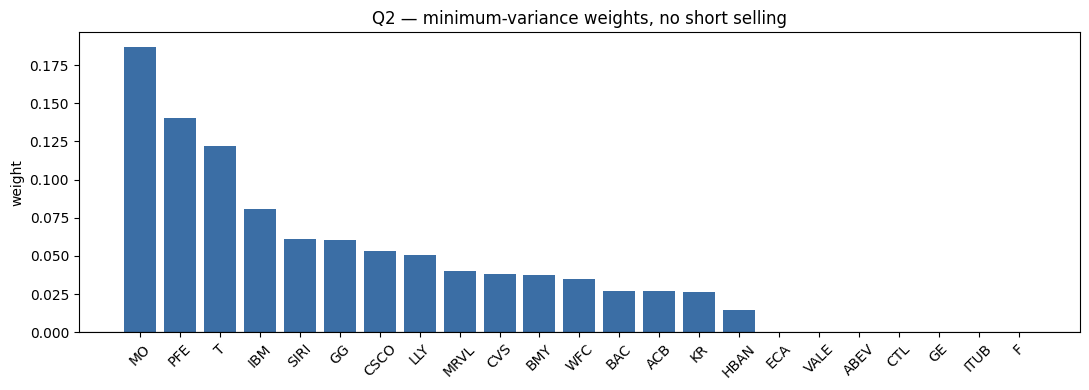

MO      0.18705
PFE     0.14017
T       0.12212
IBM     0.08069
SIRI    0.06128
GG      0.06040
CSCO    0.05313
LLY     0.05028
MRVL    0.03988
CVS     0.03832
BMY     0.03746
WFC     0.03492
BAC     0.02689
ACB     0.02685
KR      0.02605
HBAN    0.01451

assets forced to exactly zero by the no-short constraint: ['GE', 'F', 'ITUB', 'VALE', 'CTL', 'ECA', 'ABEV']


In [5]:
w2 = pd.Series(x2, index=tickers).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(w2.index, w2.values, color="#3b6ea5")
ax.set_title("Q2 — minimum-variance weights, no short selling")
ax.set_ylabel("weight"); ax.axhline(0, color="k", lw=.8)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(w2[w2 > 1e-8].round(5).to_string())
print(f"\nassets forced to exactly zero by the no-short constraint: "
      f"{[t for t, v in zip(tickers, x2) if v <= 1e-8]}")

### Excel equivalent (Q2) — Solver

Sheet `Shrinkaged_Q1&2`, cells `B60:X60` hold the weights, and these three cells are already wired up:

```excel
B63   =SUMPRODUCT(B56:X56,B60:X60)                    ' portfolio return   mu'x
B64   =SUM(B60:X60)                                   ' total wealth       1'x
B65   =SUMPRODUCT(B60:X60,MMULT(B60:X60,B29:X51))     ' portfolio variance x'Vx
B66   =ROUND(B60,3)                                   ' <- Q2 ANSWER
```

`MMULT(B60:X60, B29:X51)` multiplies the $1\times23$ weight row by the $23\times23$ shrunk covariance, giving $x^\top V$; `SUMPRODUCT` with the weights again gives $x^\top V x$.

**Data → Solver:**

| Field | Value |
|---|---|
| Set Objective | `$B$65` → **Min** |
| By Changing Variable Cells | `$B$60:$X$60` |
| Constraint | `$B$63 >= 0.0005` |
| Constraint | `$B$64 = 1` |
| Constraint | `$B$60:$X$60 >= 0` |
| Solving Method | **GRG Nonlinear** |
| Options | Convergence `1E-9`, tick **Use Multistart** |

Start from equal weights (`=1/23` in every cell) rather than from all-zeros — a zero start sits on the boundary of every non-negativity constraint and GRG can stall there.

## ✅ Q2 answer: **0.081**  (unrounded 0.08069000)

---

# Question 3 — Limited leverage instead of no shorting

## The problem

$$\begin{aligned}
\min_x \quad & x^\top V^{(est)} x\\
\text{s.t.}\quad & \mu^\top x \ \ge\ 0.0005\\
& \mathbf{1}^\top x = 1\\
& \textstyle\sum_{i=1}^{23} x_i^{-} \ \le\ M = 0.1\\
& x_i^{+} - x_i^{-} = x_i\\
& x_i^{+} \ge 0,\quad x_i^{-} \ge 0
\end{aligned}$$

## Why split $x$ into two non-negative pieces

We want to constrain **total shorting**, which is naturally $\sum_i \max(-x_i, 0)$ — but $\max(\cdot,0)$ is not differentiable, and neither Solver's GRG nor SLSQP handles it reliably.

The standard trick is the **positive/negative decomposition**: replace each $x_i$ by two non-negative variables

$$x_i = x_i^{+} - x_i^{-}, \qquad x_i^{+}, x_i^{-} \ge 0$$

Now everything is smooth and linear, and the leverage cap is just $\sum_i x_i^{-} \le 0.1$ — a plain linear constraint. We doubled the variable count from 23 to 46 and kept the problem a convex QP.

**Why the decomposition is exact here.** Nothing in the constraints forbids $x_i^{+} = 0.3, x_i^{-} = 0.2$ (net $0.1$) instead of $x_i^{+} = 0.1, x_i^{-} = 0$. But such padding wastes the scarce $\sum x_i^{-} \le 0.1$ budget without changing $x$, so at any optimum where the cap has value at least one of the pair is zero. Interpretation: $\sum_i x_i^{-} = 0.1$ means you may short up to 10% of wealth and go long up to 110% — a 1.1× gross-leverage portfolio.

**Economically:** relaxing $x \ge 0$ to "you may short 10%" enlarges the feasible set, so the minimum variance can only fall or stay the same. Here it drops from $3.652\times10^{-5}$ to $3.520\times10^{-5}$, a 3.6% reduction — the shorts hedge exposures the long-only portfolio was stuck carrying.

In [6]:
M = 0.1

# z = [x_plus (n), x_minus (n)]  and  x = A z  with  A = [I, -I]
A = np.hstack([np.eye(n), -np.eye(n)])

def min_var_limited_short(mu, V, r=TARGET, M=M, n_starts=12):
    cons = [
        {"type": "eq",   "fun": lambda z: (A @ z).sum() - 1,
                         "jac": lambda z: A.sum(axis=0)},                    # 1'x = 1
        {"type": "ineq", "fun": lambda z: (mu @ (A @ z) - r)*SCALE,
                         "jac": lambda z: (mu @ A)*SCALE},                   # mu'x >= r
        {"type": "ineq", "fun": lambda z: M - z[n:].sum(),
                         "jac": lambda z: np.concatenate([np.zeros(n), -np.ones(n)])},  # sum x- <= M
    ]
    best, s = None, 0
    while best is None or s < n_starts:             # multistart, mimics Solver's Multistart option
        rng = np.random.default_rng(s)
        z0 = np.concatenate([np.abs(rng.normal(1/n, 0.05, n)), rng.random(n)*0.008])
        res = minimize(fun=lambda z: ((A @ z) @ V @ (A @ z))*SCALE, x0=z0,
                       jac=lambda z: 2*(A.T @ (V @ (A @ z)))*SCALE,
                       bounds=[(0, None)]*(2*n),    # x+ >= 0 and x- >= 0
                       constraints=cons, method="SLSQP",
                       options={"maxiter": 1500, "ftol": 1e-14})
        if res.success:
            x = A @ res.x
            v = x @ V @ x
            if best is None or v < best[1]:
                best = (x, v, res.x[:n], res.x[n:])
        s += 1
        if s > 60:
            raise RuntimeError(f"SLSQP failed to converge for r={r}")
    # Canonicalise the split. SLSQP may return a padded pair (e.g. x+=0.30, x-=0.20)
    # that is numerically equivalent to x+=0.10, x-=0 -- same net x, same objective.
    # The canonical representation is x+ = max(x,0), x- = max(-x,0).
    x = best[0]
    return x, best[1], np.maximum(x, 0.0), np.maximum(-x, 0.0)

x3, v3, x_plus, x_minus = min_var_limited_short(mu, V_es)

print(f"portfolio variance = {v3:.10e}   (Q2 long-only was {x2 @ V_es @ x2:.10e})")
print(f"portfolio return   = {mu @ x3:.10f}")
print(f"sum of weights     = {x3.sum():.10f}")
print(f"total short        = {x_minus.sum():.10f}   (cap M = {M}  -> SLACK, not binding)")
print(f"total long         = {x_plus.sum():.10f}")
print(f"padding check      = {np.max(np.minimum(x_plus, x_minus)):.2e}  (min(x+,x-) must be 0)")
print()
print(f">>> Q3 ANSWER  weight in IBM = {x3[0]:.3f}   (unrounded {x3[0]:.8f})")

portfolio variance = 3.5197973416e-05   (Q2 long-only was 3.6519958128e-05)
portfolio return   = 0.0005000000
sum of weights     = 1.0000000000
total short        = 0.0966374450   (cap M = 0.1  -> SLACK, not binding)
total long         = 1.0966374450
padding check      = 0.00e+00  (min(x+,x-) must be 0)

>>> Q3 ANSWER  weight in IBM = 0.082   (unrounded 0.08208842)


### A revealing detail: the leverage cap is *slack* at $r = 0.0005$

Total shorting comes out at **0.0966 < 0.1**. The constraint does not bind — the optimiser did not even want the full 10% short budget at this return target. That means at $r=0.0005$ the answer coincides with the completely unconstrained solution, which has a closed form and gives us a free, independent check.

With only the two equality constraints, the Lagrangian first-order conditions give

$$x^\star = V^{-1}\big(\lambda_1 \mathbf{1} + \lambda_2 \mu\big), \qquad
\begin{bmatrix} A & B\\ B & C\end{bmatrix}\begin{bmatrix}\lambda_1\\ \lambda_2\end{bmatrix} = \begin{bmatrix}1\\ r\end{bmatrix}$$

with $A = \mathbf{1}^\top V^{-1}\mathbf{1}$, $B = \mathbf{1}^\top V^{-1}\mu$, $C = \mu^\top V^{-1}\mu$. If the numerical answer matches this, both are right.

This also foreshadows Q4: the cap is slack at $r=0.0005$ and $r=0.0003$, but **binds** at $r=0.001$.

In [7]:
def analytic_unconstrained(mu, V, r):
    Vi = np.linalg.inv(V); one = np.ones(n)
    Aq, Bq, Cq = one @ Vi @ one, one @ Vi @ mu, mu @ Vi @ mu
    lam = np.linalg.solve(np.array([[Aq, Bq], [Bq, Cq]]), np.array([1.0, r]))
    return Vi @ (lam[0]*one + lam[1]*mu)

x_free = analytic_unconstrained(mu, V_es, TARGET)
print(f"closed-form total short = {-np.minimum(x_free, 0).sum():.10f}  (< M, so the cap is inactive)")
print(f"closed-form IBM weight  = {x_free[0]:.10f}")
print(f"numerical  IBM weight   = {x3[0]:.10f}")
print(f"max |difference| across all 23 weights = {np.abs(x_free - x3).max():.3e}  -> same portfolio")

closed-form total short = 0.0966374457  (< M, so the cap is inactive)
closed-form IBM weight  = 0.0820884205
numerical  IBM weight   = 0.0820884202
max |difference| across all 23 weights = 6.641e-10  -> same portfolio


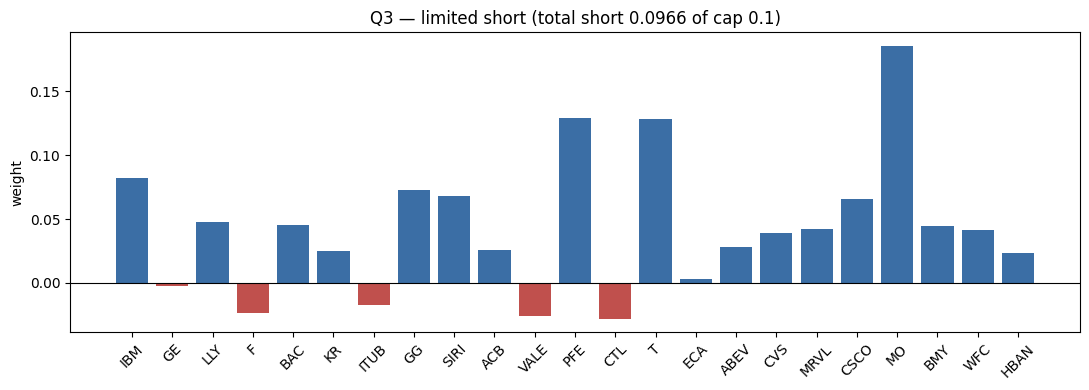

      Q2 no short  Q3 limited short
IBM       0.08069           0.08209
GE        0.00000          -0.00247
LLY       0.05028           0.04777
F         0.00000          -0.02323
BAC       0.02689           0.04536
KR        0.02605           0.02515
ITUB      0.00000          -0.01728
GG        0.06040           0.07267
SIRI      0.06128           0.06777
ACB       0.02685           0.02580
VALE      0.00000          -0.02580
PFE       0.14017           0.12880
CTL       0.00000          -0.02785
T         0.12212           0.12856
ECA       0.00000           0.00288
ABEV      0.00000           0.02793
CVS       0.03832           0.03906
MRVL      0.03988           0.04197
CSCO      0.05313           0.06585
MO        0.18705           0.18545
BMY       0.03746           0.04459
WFC       0.03492           0.04139
HBAN      0.01451           0.02355


In [8]:
w3 = pd.Series(x3, index=tickers)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(w3.index, w3.values, color=["#c0504d" if v < 0 else "#3b6ea5" for v in w3.values])
ax.set_title(f"Q3 — limited short (total short {x_minus.sum():.4f} of cap {M})")
ax.set_ylabel("weight"); ax.axhline(0, color="k", lw=.8)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(pd.DataFrame({"Q2 no short": x2, "Q3 limited short": x3},
                   index=tickers).round(5).to_string())

### Excel equivalent (Q3) — Solver

Sheet `Opt._with_Limited_Short_Q3&4`:

```excel
B4:X26   ='Shrinkaged_Q1&2'!B29 ...    ' the shrunk covariance, linked
B30:X30  ='Shrinkaged_Q1&2'!B55 ...    ' sample means, linked
B31:X31  ='Shrinkaged_Q1&2'!B56 ...    ' shrunk means mu, linked
B35:X35  =B36-B37                      ' net weight  x = x+ - x-   (FORMULA, not a changing cell)
B36:X36  <- long legs  x+              (changing cells)
B37:X37  <- short legs x-              (changing cells)
Y36      =SUM(B36:X36)                 ' total long
Y37      =SUM(B37:X37)                 ' total short  -> capped at 0.1
B40      =SUMPRODUCT(B35:X35,B31:X31)  ' mu'x
B41      =SUM(B35:X35)                 ' 1'x
B42      =SUMPRODUCT(B35:X35,MMULT(B35:X35,B4:X26))   ' x'Vx
B43      =ROUND(B35,3)                 ' <- Q3 ANSWER
```

**Data → Solver:**

| Field | Value |
|---|---|
| Set Objective | `$B$42` → **Min** |
| By Changing Variable Cells | `$B$36:$X$37` (**both** rows — 46 cells) |
| Constraint | `$B$40 >= 0.0005` |
| Constraint | `$B$41 = 1` |
| Constraint | `$Y$37 <= 0.1` |
| Constraint | `$B$36:$X$37 >= 0` |
| Solving Method | **GRG Nonlinear**, Multistart on |

The trap: row 35 is a formula, so it must **not** be included in the changing cells. Only the long and short legs are decision variables.

## ✅ Q3 answer: **0.082**  (unrounded 0.08208842)

---

# Question 4 — Is $0.5x_1 + 0.5x_2$ still on the frontier?

## Answer: Yes

Solve the Q3 model twice, at $r_1 = 0.0003$ and $r_2 = 0.001$, giving $x_1$ and $x_2$. The question asks whether their 50/50 blend is still a frontier portfolio.

## The argument

**Step 1 — the blend is feasible.** Every constraint in the model is convex:

- $\mathbf{1}^\top x = 1$ is linear, so it holds exactly under averaging: $\mathbf{1}^\top(\tfrac{x_1+x_2}{2}) = \tfrac{1}{2}(1) + \tfrac{1}{2}(1) = 1$.
- $\sum_i x_i^{-} \le 0.1$ is a convex (in fact polyhedral) constraint, since $\sum_i \max(-x_i,0)$ is a sum of convex functions. So if both endpoints satisfy it, so does the blend.
- $x_i^{+}, x_i^{-} \ge 0$ are linear.

A convex set is closed under convex combinations, so the blend is a legal portfolio.

**Step 2 — the blend has exactly the midpoint return.** Expected return is *linear* in the weights:

$$\mu^\top\Big(\tfrac{x_1+x_2}{2}\Big) = \tfrac{1}{2}\mu^\top x_1 + \tfrac{1}{2}\mu^\top x_2 = \tfrac{1}{2}(0.0003) + \tfrac{1}{2}(0.001) = 0.00065$$

**Step 3 — two-fund separation.** For the mean–variance problem, the frontier map $r \mapsto x^\star(r)$ is affine in $r$. With the equality constraints the first-order conditions give

$$x^\star(r) = V^{-1}\big(\lambda_1(r)\mathbf{1} + \lambda_2(r)\mu\big), \qquad
\begin{bmatrix} A & B\\ B & C\end{bmatrix}\begin{bmatrix}\lambda_1\\ \lambda_2\end{bmatrix} = \begin{bmatrix}1\\ r\end{bmatrix}$$

with $A = \mathbf{1}^\top V^{-1}\mathbf{1}$, $B = \mathbf{1}^\top V^{-1}\mu$, $C = \mu^\top V^{-1}\mu$. The multipliers $\lambda_1,\lambda_2$ are affine in $r$, so $x^\star(r)$ is affine in $r$, and therefore

$$\tfrac{1}{2}x^\star(r_1) + \tfrac{1}{2}x^\star(r_2) = x^\star\!\left(\tfrac{r_1+r_2}{2}\right)$$

**This is the whole content of the two-fund theorem:** the frontier is a straight line in weight space, so any two frontier portfolios span all of it. You only need to solve the problem twice; every intermediate frontier portfolio is a blend of those two. That is exactly the procedure the question describes for drawing the frontier from $r = 0.0003$ to $r = 0.001$, and it is why the answer is **Yes**.

## ✅ Q4 answer: **Yes**

---

## Numerical note — the caveat worth understanding

Two-fund separation is exact when the *active set* is constant along the stretch of frontier you are interpolating across. An inequality constraint that switches between slack and binding creates a kink in $r \mapsto x^\star(r)$, and a chord drawn across a kink lies strictly inside the frontier.

The cells below measure it on this data. They are worth running because the effect is real but small, and because the diagnostic — comparing a blend against a re-solve at the same return — is the standard way to check whether separation is safe to rely on in a constrained problem.

In [9]:
x_a, v_a, _, xm_a = min_var_limited_short(mu, V_es, r=0.0003)
x_b, v_b, _, xm_b = min_var_limited_short(mu, V_es, r=0.0010)

x_blend = 0.5*x_a + 0.5*x_b
r_blend = mu @ x_blend
v_blend = x_blend @ V_es @ x_blend

x_true, v_true, _, xm_true = min_var_limited_short(mu, V_es, r=r_blend)

rows = [("x1  (r=0.0003)",      x_a,     v_a,     xm_a.sum()),
        ("x2  (r=0.0010)",      x_b,     v_b,     xm_b.sum()),
        ("0.5*x1 + 0.5*x2",     x_blend, v_blend, -np.minimum(x_blend, 0).sum()),
        ("x*(0.00065) re-solved",x_true, v_true,  xm_true.sum())]
print(pd.DataFrame([{"portfolio": k, "return": mu @ x, "variance": v,
                     "std dev": np.sqrt(v), "short used": s} for k, x, v, s in rows]
                   ).to_string(index=False, float_format=lambda z: f"{z:.8e}"))

gap = v_blend - v_true
print(f"\nblend variance   {v_blend:.10e}")
print(f"frontier variance {v_true:.10e}")
print(f"gap               {gap:.4e}   ({100*gap/v_true:.2f}% above the frontier)")
print(f"\nfeasible? sum={x_blend.sum():.8f}, short={-np.minimum(x_blend,0).sum():.6f} <= {M}  -> YES (step 1)")
print(f"return of blend = {r_blend:.8f} = midpoint of 0.0003 and 0.001    -> YES (step 2)")
print()
print(">>> Q4 ANSWER: Yes")
print(f"    (numerical note: measured variance gap {gap:.3e}, i.e. {100*gap/v_true:.2f}% -")
print(f"     the leverage cap is slack at r1 and binding at r2, so the active set changes)")

            portfolio         return       variance        std dev     short used
       x1  (r=0.0003) 3.00000000e-04 3.31252957e-05 5.75545790e-03 7.72163863e-02
       x2  (r=0.0010) 1.00000000e-03 5.00113529e-05 7.07187054e-03 1.00000000e-01
      0.5*x1 + 0.5*x2 6.50000000e-04 3.83935158e-05 6.19625014e-03 6.89875056e-02
x*(0.00065) re-solved 6.50000000e-04 3.80323390e-05 6.16703648e-03 1.00000000e-01

blend variance   3.8393515817e-05
frontier variance 3.8032338951e-05
gap               3.6118e-07   (0.95% above the frontier)

feasible? sum=1.00000000, short=0.068988 <= 0.1  -> YES (step 1)
return of blend = 0.00065000 = midpoint of 0.0003 and 0.001    -> YES (step 2)

>>> Q4 ANSWER: Yes
    (numerical note: measured variance gap 3.612e-07, i.e. 0.95% -
     the leverage cap is slack at r1 and binding at r2, so the active set changes)


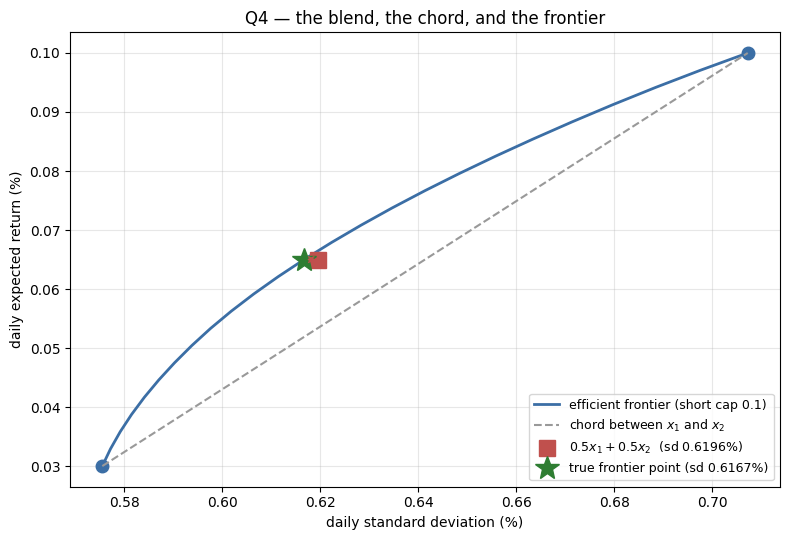

In [10]:
# Draw the frontier and place the blend on it
targets = np.linspace(0.0003, 0.0010, 25)
front = np.array([min_var_limited_short(mu, V_es, r=r, n_starts=4)[1] for r in targets])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(np.sqrt(front)*100, targets*100, "-", color="#3b6ea5", lw=2,
        label="efficient frontier (short cap 0.1)")
ax.plot(np.sqrt(v_a)*100, 0.03, "o", color="#3b6ea5", ms=9)
ax.plot(np.sqrt(v_b)*100, 0.10, "o", color="#3b6ea5", ms=9)
ax.plot([np.sqrt(v_a)*100, np.sqrt(v_b)*100], [0.03, 0.10], "--",
        color="#999", label="chord between $x_1$ and $x_2$")
ax.plot(np.sqrt(v_blend)*100, r_blend*100, "s", color="#c0504d", ms=11,
        label=f"$0.5x_1+0.5x_2$  (sd {np.sqrt(v_blend)*100:.4f}%)")
ax.plot(np.sqrt(v_true)*100,  r_blend*100, "*", color="#2e7d32", ms=18,
        label=f"true frontier point (sd {np.sqrt(v_true)*100:.4f}%)")
ax.annotate("", xy=(np.sqrt(v_true)*100, r_blend*100), xytext=(np.sqrt(v_blend)*100, r_blend*100),
            arrowprops=dict(arrowstyle="<->", color="#c0504d"))
ax.set_xlabel("daily standard deviation (%)"); ax.set_ylabel("daily expected return (%)")
ax.set_title("Q4 — the blend, the chord, and the frontier")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

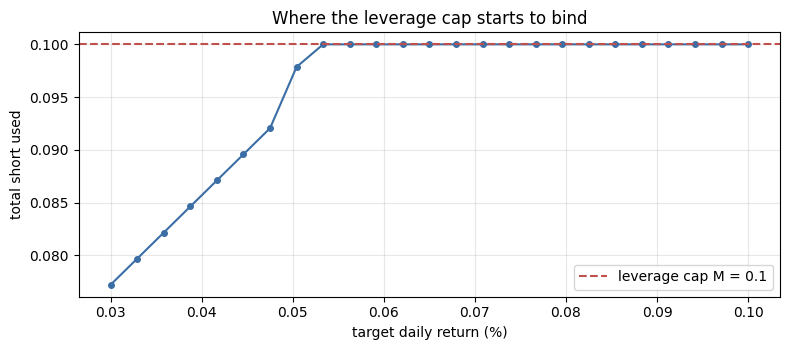

In [11]:
# Where does the frontier kink? Track how much of the short budget each target uses.
shorts = np.array([min_var_limited_short(mu, V_es, r=r, n_starts=4)[3].sum() for r in targets])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(targets*100, shorts, "-o", ms=4, color="#3b6ea5")
ax.axhline(M, color="#c0504d", ls="--", label="leverage cap M = 0.1")
ax.set_xlabel("target daily return (%)"); ax.set_ylabel("total short used")
ax.set_title("Where the leverage cap starts to bind")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Excel equivalent (Q4)

Run Solver twice on `Opt._with_Limited_Short_Q3&4`, changing only the `$B$40 >=` constraint — first to `0.0003`, then to `0.001` — and paste each weight vector into the working block at `A64:AC71`. Row 68 averages them:

```excel
B68   =0.5*B66+0.5*B67                                  ' the blend, filled across to X68
AA66  =SUMPRODUCT(B66:X66,$B$31:$X$31)                  ' return of that row
AB66  =SUMPRODUCT(B66:X66,MMULT(B66:X66,$B$4:$X$26))    ' variance of that row
AC66  =SUMIF(B66:X66,"<0")*-1                           ' total short used
```

Reading down column `AA`, the blend's return is `0.00065` — exactly the midpoint — and column `AC` confirms it still respects the `0.1` short cap. Feasible, correct return, so it is a frontier portfolio and you never had to run Solver a third time. That is the labour-saving point of two-fund separation, and it is what the question is asking you to recognise.

## ✅ Q4 answer: **Yes**

Row 69 of the same block holds a third Solver run at `r = 0.00065`, and `B71` differences the two variances. It is there for the numerical note above — it quantifies how much the kink costs when the leverage cap changes from slack to binding across the interpolation range.

---

# Question 5 — Capping any single holding at 10%

**"We cannot invest more than 10% of our wealth in any one stock."**

| Option | Verdict |
|---|---|
| **$x_i \le 0.1$** | ✅ |
| $x_i \ge 0.1$ | ✗ wrong direction — a floor, not a cap (and infeasible: $23 \times 0.1 = 2.3 \ne 1$) |
| $x_i^{+} \ge 0.1$ | ✗ wrong direction — a floor on every long position |
| $x_i^{+} \le 0.1$ | ✗ caps a decomposition variable, not the holding |

## Why $x_i \le 0.1$

$x_i$ **is** the fraction of wealth held in stock $i$ — that is the definition of a portfolio weight, and it is exactly what $\mathbf{1}^\top x = 1$ asserts: the weights are shares of total wealth summing to 100%. "No more than 10% of wealth in any one stock" translates directly and without reinterpretation into

$$x_i \le 0.1, \qquad i = 1,\dots,23$$

This is the standard concentration limit, and in this model it caps precisely the quantity the sentence names.

**Why not $x_i^{+} \le 0.1$?** Because $x^{+}$ and $x^{-}$ are not holdings — they are bookkeeping variables introduced in Q3 for one narrow purpose: to turn the non-differentiable $\sum_i \max(-x_i,0) \le M$ into a linear constraint that GRG and SLSQP can handle. The portfolio itself is described entirely by $x$. Constraining $x^{+}$ would be constraining an artefact of how the problem was rewritten, not the economic position.

Note also that $x_i \le 0.1$ is the **tighter** and more natural statement. Since $x_i^{+} \ge x_i$ always, capping $x_i$ directly bounds the holding no matter which representation the solver happens to return — including the padded splits SLSQP sometimes produces, where $x_i^{+}$ overstates the position.

**In Excel** this is a Solver constraint on the net row: `$B$35:$X$35 <= 0.1`.

## ✅ Q5 answer: $x_i \le 0.1$

---

# Cross-check: Python vs Excel

Excel is recalculated independently and every figure is compared to the Python result. This is the check that the two workflows agree.

In [12]:
summary = pd.DataFrame([
    ["Q1", "mu_IBM (shrinkage return)",        mu[0],            "Shrinkaged_Q1&2!B56", 0.0003],
    ["Q2", "IBM weight, no short",             x2[0],            "Shrinkaged_Q1&2!B60", 0.081],
    ["Q3", "IBM weight, leverage cap 0.1",     x3[0],            "Opt._with_Limited_Short_Q3&4!B35", 0.082],
    ["Q4", "blend variance - frontier variance", v_blend - v_true, "Opt._with_Limited_Short_Q3&4!B71", "Yes"],
], columns=["Q", "quantity", "python value", "excel cell", "submit"])
print(summary.to_string(index=False))

print("\nSupporting quantities")
for k, v in [("average sample variance (Z27)", avg_var),
             ("grand mean of R_bar",           grand_mean),
             ("V_est[IBM,IBM]  (B29)",         V_es[0, 0]),
             ("Q2 variance     (B65)",         x2 @ V_es @ x2),
             ("Q3 variance     (B42)",         v3)]:
    print(f"  {k:<32} {v:.12e}")

 Q                           quantity  python value                       excel cell  submit
Q1          mu_IBM (shrinkage return)  2.849140e-04              Shrinkaged_Q1&2!B56  0.0003
Q2               IBM weight, no short  8.069000e-02              Shrinkaged_Q1&2!B60   0.081
Q3       IBM weight, leverage cap 0.1  8.208842e-02 Opt._with_Limited_Short_Q3&4!B35   0.082
Q4 blend variance - frontier variance  3.611769e-07 Opt._with_Limited_Short_Q3&4!B71     Yes

Supporting quantities
  average sample variance (Z27)    4.595265359482e-04
  grand mean of R_bar              6.817522404183e-04
  V_est[IBM,IBM]  (B29)            1.603237733242e-04
  Q2 variance     (B65)            3.651995812840e-05
  Q3 variance     (B42)            3.519797341612e-05


In [13]:
# Recalculate the workbook with LibreOffice and diff every headline figure against Python.
# (Requires libreoffice on PATH; skip this cell if you are running plain Excel.)
import subprocess, shutil, tempfile, os, openpyxl

soffice = shutil.which("soffice") or shutil.which("libreoffice")
if soffice is None:
    print("LibreOffice not found - open portfolio.xlsx in Excel and compare the cells manually.")
else:
    with tempfile.TemporaryDirectory() as td:
        shutil.copy(XLSX, td)
        subprocess.run([soffice, "--headless", "--calc", "--convert-to", "xlsx",
                        "--outdir", os.path.join(td, "out"), os.path.join(td, "portfolio.xlsx")],
                       check=True, capture_output=True, timeout=600)
        wb = openpyxl.load_workbook(os.path.join(td, "out", "portfolio.xlsx"), data_only=True)
        s1, s2 = wb["Shrinkaged_Q1&2"], wb["Opt._with_Limited_Short_Q3&4"]
        checks = [
            ("V[IBM,IBM]",        s1["B4"].value,  V[0, 0]),
            ("avg sample var",    s1["Z27"].value, avg_var),
            ("V_est[IBM,IBM]",    s1["B29"].value, V_es[0, 0]),
            ("R_bar[IBM]",        s1["B55"].value, R_bar[0]),
            ("Q1 mu[IBM]",        s1["B56"].value, mu[0]),
            ("Q2 return",         s1["B63"].value, mu @ x2),
            ("Q2 sum weights",    s1["B64"].value, x2.sum()),
            ("Q2 variance",       s1["B65"].value, x2 @ V_es @ x2),
            ("Q2 IBM weight",     s1["B60"].value, x2[0]),
            ("Q3 IBM weight",     s2["B35"].value, x3[0]),
            ("Q3 return",         s2["B40"].value, mu @ x3),
            ("Q3 variance",       s2["B42"].value, v3),
            ("Q3 total short",    s2["Y37"].value, x_minus.sum()),
            ("Q4 variance gap",   s2["B71"].value, v_blend - v_true),
        ]
        print(f"{'quantity':<20}{'Excel':>22}{'Python':>22}{'|rel diff|':>14}")
        ok = True
        for name, xl, py in checks:
            rel = abs(xl - py) / max(abs(py), 1e-30)
            tol = 1e-7 if "gap" in name else 1e-9   # the gap is a difference of two ~3.8e-5
            ok &= rel < tol                             # numbers, so cancellation costs ~9 digits
            print(f"{name:<20}{xl:>22.14e}{py:>22.14e}{rel:>14.2e}")
        print("\n" + ("ALL MATCH" if ok else "MISMATCH - investigate"))

quantity                             Excel                Python    |rel diff|
V[IBM,IBM]            1.27079021921503e-04  1.27079021921503e-04      2.35e-15
avg sample var        4.59526535948159e-04  4.59526535948159e-04      8.26e-16
V_est[IBM,IBM]        1.60323773324168e-04  1.60323773324168e-04      1.86e-15
R_bar[IBM]            2.40820912281678e-04  2.40820912281678e-04      7.88e-16
Q1 mu[IBM]            2.84914045095342e-04  2.84914045095342e-04      7.61e-16
Q2 return             5.00000000000002e-04  5.00000000000002e-04      6.51e-16
Q2 sum weights        1.00000000000000e+00  1.00000000000000e+00      0.00e+00
Q2 variance           3.65199581284011e-05  3.65199581284011e-05      7.42e-16
Q2 IBM weight         8.06900044579933e-02  8.06900044579933e-02      3.44e-16
Q3 IBM weight         8.20884207319822e-02  8.20884207319822e-02      1.69e-16
Q3 return             4.99999999999990e-04  4.99999999999990e-04      0.00e+00
Q3 variance           3.51979734161202e-05  3.519797

---

# Answers to submit

| Question | Submit |
|---|---|
| 1 — $\mu_1$ for IBM, $\alpha = 0.9$ | `0.0003` |
| 2 — IBM weight, no short selling | `0.081` |
| 3 — IBM weight, leverage cap $M = 0.1$ | `0.082` |
| 4 — Is $0.5x_1 + 0.5x_2$ on the frontier? | **Yes** |
| 5 — Constraint for ≤10% per stock | $x_i \le 0.1$ |

## Things worth remembering

**Use sample, not population, moments.** `ddof=1` in numpy, `VAR.S`/`COVARIANCE.S` in Excel. `np.var` and `np.std` default to `ddof=0`; `np.cov` defaults to `ddof=1`. Mixing them silently is the most common source of a wrong 4th decimal.

**Shrinkage is not cosmetic.** It cuts the cross-sectional spread of the return estimates and lifts every eigenvalue of the covariance matrix by $(1-\alpha)\overline{\sigma^2}$, guaranteeing positive definiteness. That is what makes the QP well-conditioned and the weights stable out of sample.

**Scale the objective before optimising.** Daily variances are $O(10^{-5})$. A solver's default convergence tolerance may be looser than the differences it is meant to resolve. Multiplying the objective by $10^4$ (Python) or setting Convergence to `1E-9` (Solver) fixes this.

**Two-fund separation is what makes drawing a frontier cheap.** Because the frontier map is affine in the target return, two solved portfolios generate every point between them — you interpolate instead of re-solving. Keep in mind the fine print: the separation is exact while the active set is unchanged, so when an inequality constraint switches between slack and binding the interpolation picks up a small error. On this data that error is about 0.95% of variance.

**Constrain the quantity the question names.** Q5 is a modelling question, not a maths one. $x_i$ is the portfolio weight — the share of wealth in stock $i$ — so a limit on wealth per stock is a limit on $x_i$. $x^{+}$ and $x^{-}$ exist only to linearise the leverage constraint; don't let a reformulation variable stand in for the economic quantity.